In [1]:
import pandas as pd
import seaborn as sns

In [2]:
def get_annotations(task):
    annotations = pd.read_csv(f'../data/{task}/{task}.bed', sep="\t", low_memory=False)
    annotations['length'] = annotations['end'] - annotations['start']

    return annotations


annotations = get_annotations('cpg_methylation')
annotations

,chromosome,start,end,strand,label,split,length
0,chr1,134839,135351,+,"0,1,2,3,4,5,6",train,512
1,chr1,134946,135458,+,"0,1,2,3,4,5,6",train,512
2,chr1,134951,135463,+,"0,1,2,3,4,5,6",train,512
3,chr1,139110,139622,+,"0,1,2,3,4,5,6",train,512
4,chr1,180816,181328,+,"0,1,2,3,4,5,6",train,512
...,...,...,...,...,...,...,...
959034,chrY,6535336,6535848,-,"0,1,2,3,4,5,6",train,512
959035,chrY,6535372,6535884,+,"0,1,2,3,4,5,6",train,512
959036,chrY,6744500,6745012,+,4,train,512
959037,chrY,10223411,10223923,-,NaN,train,512


In [3]:
def get_overlaps(annotations):

    annotations['prev_end'] = annotations['end'].shift(1, fill_value=pd.NA)
    annotations['prev_start'] = annotations['start'].shift(1, fill_value=pd.NA)

    mask_overlaps = ~((annotations['start']>annotations['prev_end']) | (annotations['end']<annotations['prev_start']))
    annotations = annotations[mask_overlaps]
    
    overlaps = annotations['prev_end']-annotations['start'] - (annotations['prev_start']- annotations['start']).clip(lower=0) - (annotations['prev_end']-annotations['end']).clip(lower=0)

    return overlaps, mask_overlaps

overlaps, mask_overlaps = get_overlaps(annotations)
overlaps.describe()

count    492130.000000
mean        381.238016
std         143.816634
min           0.000000
25%         298.000000
50%         449.000000
75%         497.000000
max         511.000000
dtype: float64

In [5]:
TASKS = ['histone_modification', 'gene_finding', 'enhancer_annotation','cpg_methylation', 'chromatin_accessibility']

all_sequence_overlap = []
all_weighted_overlap = []
all_tasks = []

for task in TASKS:
    annotations = get_annotations(task)
    overlaps, mask_overlaps = get_overlaps(annotations)

    print(task)
    pct_overlapping_samples = len(overlaps) / len(annotations) 
    print(f'\tpct_overlapping_samples: {round(pct_overlapping_samples*100,2)}')
    pct_sequence_overlap = overlaps / annotations['length'][mask_overlaps]*100
    print(f'\tmedian pct_sequence_overlap: {round(pct_sequence_overlap.median(),2)}')
    weighted_overlap = pct_sequence_overlap*pct_overlapping_samples
    print(f'\tmedian weighted_pct_sequence_overlap: {round(weighted_overlap.median(),2)}')

    all_sequence_overlap.extend(pct_sequence_overlap)
    all_weighted_overlap.extend(weighted_overlap)
    all_tasks.extend([task]*len(pct_sequence_overlap))

df = pd.DataFrame.from_dict({'task': all_tasks, 'sequence_overlap': all_sequence_overlap,'weighted_overlap':all_weighted_overlap })

histone_modification
	pct_overlapping_samples: 16.81
	median pct_sequence_overlap: 19.73
	median weighted_pct_sequence_overlap: 3.32
gene_finding
	pct_overlapping_samples: 9.6
	median pct_sequence_overlap: 12.93
	median weighted_pct_sequence_overlap: 1.24
enhancer_annotation
	pct_overlapping_samples: 3.16
	median pct_sequence_overlap: 54.44
	median weighted_pct_sequence_overlap: 1.72
cpg_methylation
	pct_overlapping_samples: 51.32
	median pct_sequence_overlap: 87.7
	median weighted_pct_sequence_overlap: 45.0
chromatin_accessibility
	pct_overlapping_samples: 28.11
	median pct_sequence_overlap: 20.12
	median weighted_pct_sequence_overlap: 5.66


<Axes: xlabel='task', ylabel='sequence_overlap'>

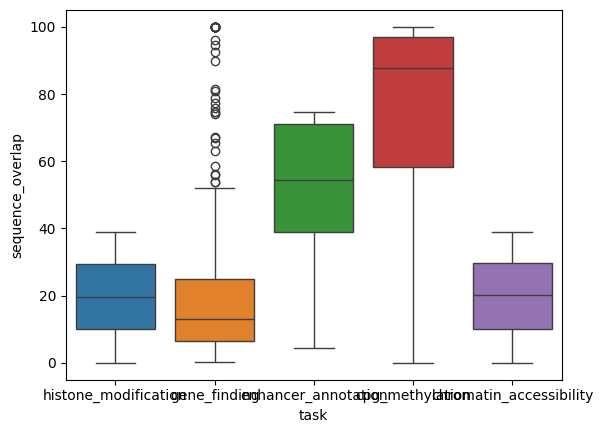

In [10]:
sns.boxplot(x=df['task'], y=df['sequence_overlap'], hue=df['task'])

<Axes: xlabel='task', ylabel='weighted_overlap'>

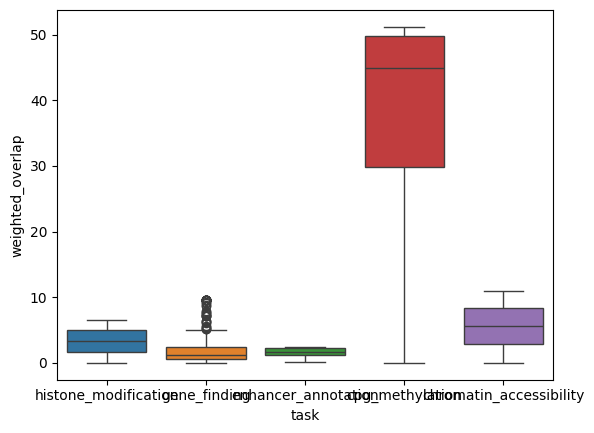

In [11]:
sns.boxplot(x=df['task'], y=df['weighted_overlap'], hue=df['task'])